
 LOGISTIC REGRESSION RESULTS

Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         9

    accuracy                           1.00         9
   macro avg       1.00      1.00      1.00         9
weighted avg       1.00      1.00      1.00         9



c:\Users\ishika\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:534: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


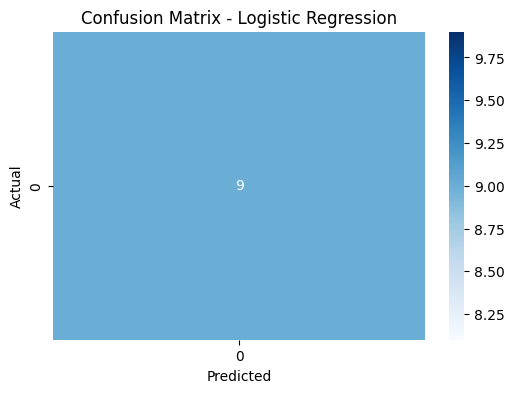

c:\Users\ishika\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_ranking.py:1201: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


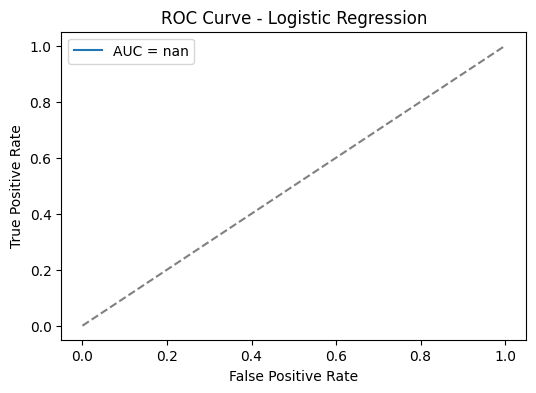

c:\Users\ishika\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_ranking.py:1046: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(


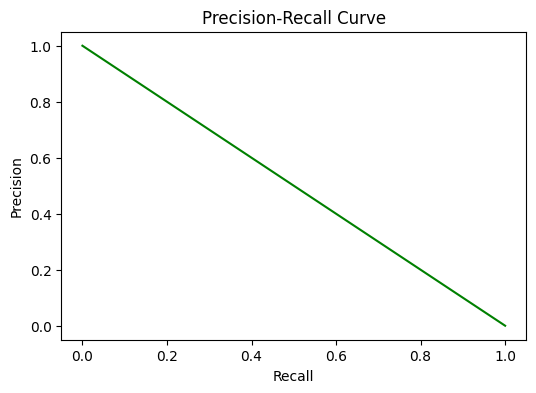

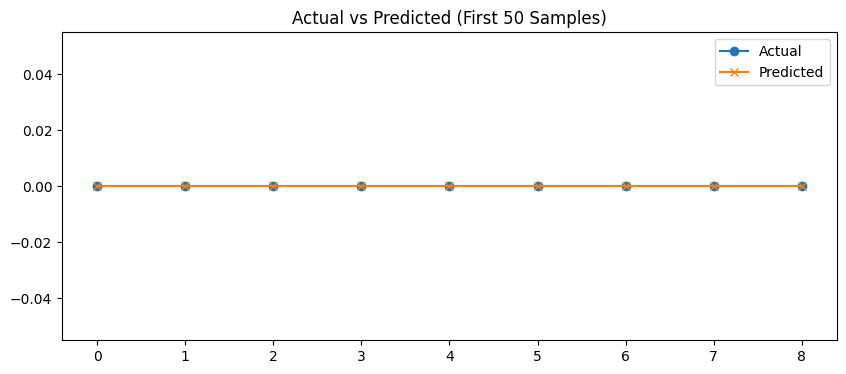

In [1]:

#  LOGISTIC REGRESSION MODEL - FULL PIPELINE


import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve
import seaborn as sns
import matplotlib.pyplot as plt

# ---------------------------
# 1. Load Cleaned Dataset
# ---------------------------
df = pd.read_csv("cleaned_dataset.csv")
df.columns = df.columns.str.strip().str.lower()

# ---------------------------
# 2. Separate X and y
# ---------------------------
y = df["dropout"]
X = df.drop(columns=["dropout"])

# ---------------------------
# 3. Label Encode Categorical Columns
# ---------------------------
le = LabelEncoder()

for col in X.select_dtypes(include=["object"]).columns:
    X[col] = le.fit_transform(X[col].astype(str))

# ---------------------------
# 4. Scaling
# ---------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ---------------------------
# 5. Train-Test Split
# ---------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# ---------------------------
# 6. Train Logistic Regression Model
# ---------------------------
log_model = LogisticRegression(max_iter=2000)
log_model.fit(X_train, y_train)

# ---------------------------
# 7. Predictions
# ---------------------------
y_pred = log_model.predict(X_test)
y_proba = log_model.predict_proba(X_test)[:,1]

# ---------------------------
# 8. Evaluation
# ---------------------------
print("\n============================")
print(" LOGISTIC REGRESSION RESULTS")
print("============================\n")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# ---------------------------
# 9. Confusion Matrix
# ---------------------------
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ---------------------------
# 10. ROC Curve
# ---------------------------
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], linestyle="--", color="gray")
plt.title("ROC Curve - Logistic Regression")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

# ---------------------------
# 11. Precision-Recall Curve
# ---------------------------
precision, recall, thresholds = precision_recall_curve(y_test, y_proba)

plt.figure(figsize=(6,4))
plt.plot(recall, precision, color="green")
plt.title("Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.show()

# ---------------------------
# 12. Actual vs Predicted Plot
# ---------------------------
plt.figure(figsize=(10,4))
plt.plot(y_test.values[:50], label="Actual", marker="o")
plt.plot(y_pred[:50], label="Predicted", marker="x")
plt.title("Actual vs Predicted (First 50 Samples)")
plt.legend()
plt.show()



 RANDOM FOREST RESULTS

Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         9

    accuracy                           1.00         9
   macro avg       1.00      1.00      1.00         9
weighted avg       1.00      1.00      1.00         9



c:\Users\ishika\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:534: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


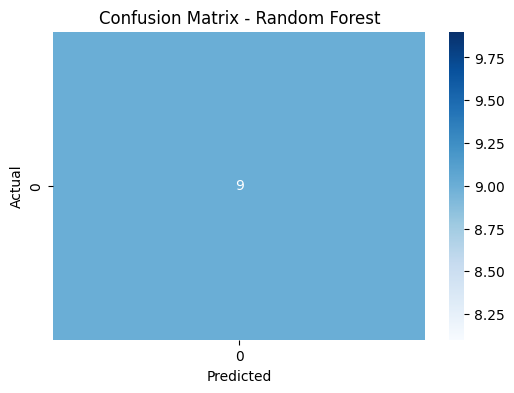

c:\Users\ishika\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_ranking.py:1201: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


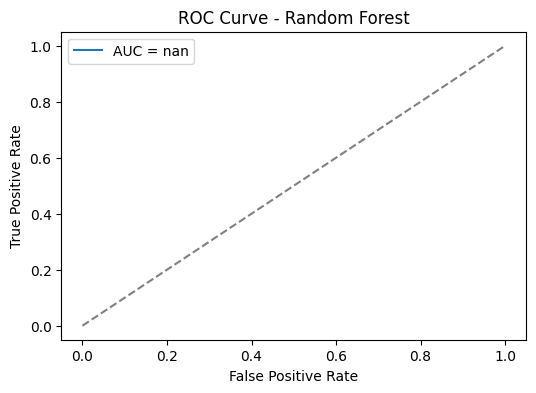

c:\Users\ishika\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_ranking.py:1046: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(


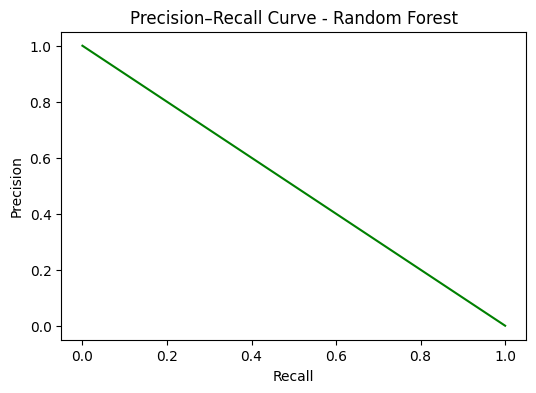

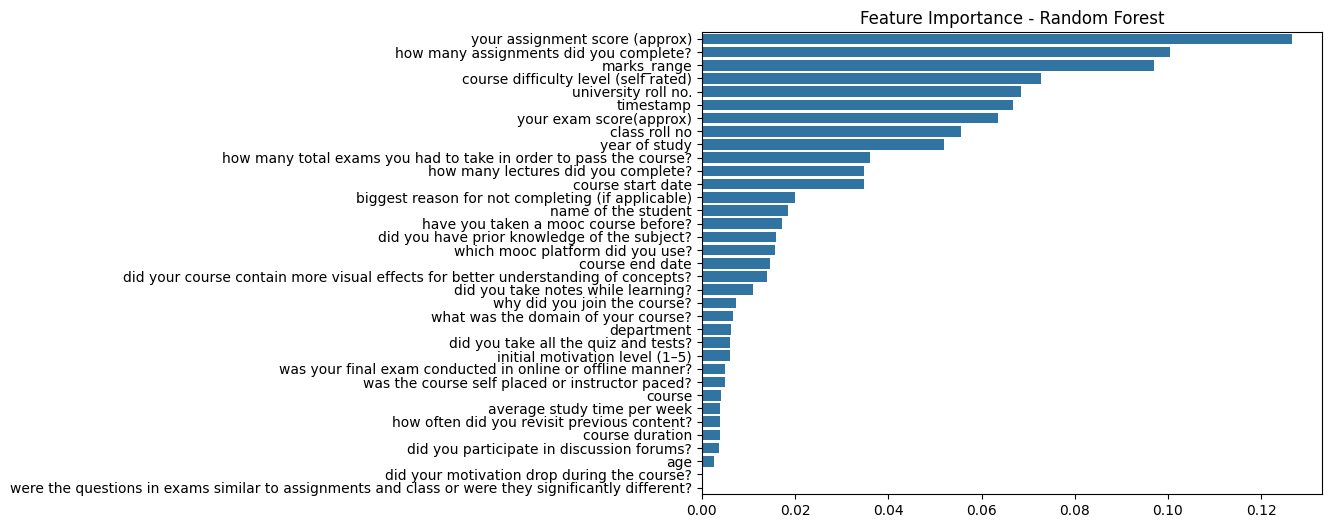

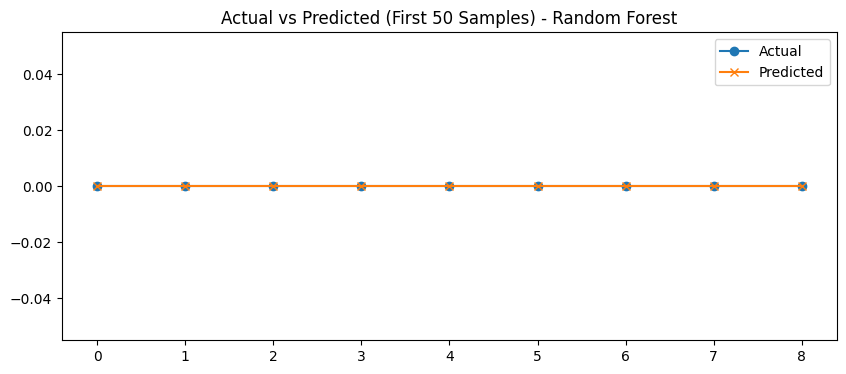

In [ ]:

#  RANDOM FOREST MODEL - FULL PIPELINE

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve
from sklearn.ensemble import RandomForestClassifier
import seaborn as sns
import matplotlib.pyplot as plt


# 1. Load Cleaned Dataset

df = pd.read_csv("cleaned_dataset.csv")
df.columns = df.columns.str.strip().str.lower()


# 2. Separate X and y
y = df["dropout"]
X = df.drop(columns=["dropout"])

# 3. Label Encoding
le = LabelEncoder()
for col in X.select_dtypes(include=["object"]).columns:
    X[col] = le.fit_transform(X[col].astype(str))


# 4. Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


# 5. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)


# 6. Train Random Forest Model
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    random_state=42
)

rf_model.fit(X_train, y_train)


# 7. Predictions
y_pred = rf_model.predict(X_test)
y_proba = rf_model.predict_proba(X_test)[:, 1]


# 8. Evaluation
print("\n============================")
print(" RANDOM FOREST RESULTS")
print("============================\n")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))



# 9. Confusion Matrix

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


# ---------------------------
# 10. ROC Curve
# ---------------------------
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1],[0,1], linestyle="--", color="gray")
plt.title("ROC Curve - Random Forest")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()


# ---------------------------
# 11. Precision-Recall Curve
# ---------------------------
precision, recall, _ = precision_recall_curve(y_test, y_proba)

plt.figure(figsize=(6,4))
plt.plot(recall, precision, color="green")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve - Random Forest")
plt.show()


# ---------------------------
# 12. Feature Importance
# ---------------------------
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]
feature_names = X.columns

plt.figure(figsize=(8,6))
sns.barplot(x=importances[indices], y=np.array(feature_names)[indices])
plt.title("Feature Importance - Random Forest")
plt.show()


# ---------------------------
# 13. Actual vs Predicted Plot
# ---------------------------
plt.figure(figsize=(10,4))
plt.plot(y_test.values[:50], label="Actual", marker="o")
plt.plot(y_pred[:50], label="Predicted", marker="x")
plt.title("Actual vs Predicted (First 50 Samples) - Random Forest")
plt.legend()
plt.show()


In [ ]:

#  XGBOOST MODEL + SAFE PREDICTION PIPELINE (ERROR-FREE)

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_curve, auc, precision_recall_curve
)
from xgboost import XGBClassifier, plot_importance

# ----------------------------------------
# 1. Load Cleaned Dataset
# ----------------------------------------
df = pd.read_csv("cleaned_dataset.csv")
df.columns = df.columns.str.strip().str.lower()

# ----------------------------------------
# 2. Separate X and y
# ----------------------------------------
y = df["dropout"]
X = df.drop(columns=["dropout"])

# ----------------------------------------
# 3. Create separate LabelEncoders for each column
# ----------------------------------------
encoders = {}

for col in X.select_dtypes(include=["object"]).columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    encoders[col] = le       # store encoder for that specific column


# 4. Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 5. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# 6. Train XGBoost Model
xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42
)

xgb_model.fit(X_train, y_train)

# 7. Predictions
y_pred = xgb_model.predict(X_test)
y_proba = xgb_model.predict_proba(X_test)[:, 1]

# 8. Evaluation
print("\n MODEL PERFORMANCE — XGBOOST")
print("----------------------------------------------------")
print(f"✔ Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\n Classification Report:")
print(classification_report(y_test, y_pred))


#  FIXED SAFE PREDICTION FUNCTION (NO MORE ERRORS)


def predict_dropout(new_input_dict):
    df_new = pd.DataFrame([new_input_dict])

    # Ensure all columns exist
    for col in X.columns:
        if col not in df_new.columns:
            df_new[col] = 0

    # Reorder
    df_new = df_new[X.columns]

    # Encode using SAVED encoders (per column)
    for col in df_new.select_dtypes(include=["object"]).columns:
        le = encoders[col]

        # unseen values handled safely
        df_new[col] = df_new[col].apply(
            lambda x: le.transform([x])[0] if x in le.classes_ else -1
        )

    # Scale
    df_new_scaled = scaler.transform(df_new)

    # Predict
    pred_class = xgb_model.predict(df_new_scaled)[0]
    pred_proba = float(xgb_model.predict_proba(df_new_scaled)[0][1])

    # Pretty output
    print("\n================ PREDICTION RESULT ================\n")
    if pred_class == 1:
        print("🚨 **HIGH RISK OF DROPOUT**")
    else:
        print(" **Student is UNLIKELY to drop out**")

    print(f"\n Dropout Probability: **{pred_proba*100:.2f}%**")
    print("\n===================================================\n")

    return pred_class, pred_proba




 MODEL PERFORMANCE — XGBOOST
----------------------------------------------------
✔ Accuracy: 1.0000

 Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         9

    accuracy                           1.00         9
   macro avg       1.00      1.00      1.00         9
weighted avg       1.00      1.00      1.00         9



In [4]:


#  SAMPLE INPUT

sample_student = {
    "course": "python",
    "department": "cse",
    "have you taken a mooc course before?": "yes",
    "which mooc platform did you use?": "coursera",
    "what was the domain of your course?": "programming",
    "course duration": "8 weeks",
    "course difficulty level (self rated)": "medium",
    "was the course self placed or instructor paced?": "self paced",
    "did your course contain more visual effects for better understanding of concepts?": "yes",
    "average study time per week": 2,
    "how many lectures did you complete?": 15,
    "how many assignments did you complete?": 4,
    "did you participate in discussion forums?": "no",
    "did you take notes while learning?": "no",
    "how often did you revisit previous content?": "rarely",
    "did you take all the quiz and tests?": "no",
    "how many total exams you had to take in order to pass the course?": 2,
    "were the questions in exams similar to assignments and class or were they significantly different?": "similar",
    "was your final exam conducted in online or offline manner?": "online",
    "why did you join the course?": "interest",
    "initial motivation level (1–5)": 3,
    "did your motivation drop during the course?": "yes",
    "biggest reason for not completing (if applicable)": "time issues",
    "did you have prior knowledge of the subject?": "no"
}

predict_dropout(sample_student) 


================ PREDICTION RESULT ================

 **Student is UNLIKELY to drop out**

 Dropout Probability: **5.39%**




(np.int64(0), 0.053886570036411285)